Сравним классические ML-алгоритмы и способы предобработки данных с целью определения наилучшего baseline, результат которого в дальнейшем необходимо превзойти

In [1]:
%load_ext autoreload
%autoreload 2

## Импорт необходимых библиотек и модулей

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from lightgbm import LGBMClassifier

In [4]:
from core.utils import *
from core.nlp import *
from core.visualization import *
from core.baseline_training import *
from core.vectorization import *

Для воспроизводимости экспериментов

In [5]:
SEED = 316

init_random_seed(SEED)

## Загрузка и препроцессинг данных

In [6]:
data_path = 'data'

In [8]:
data = pd.read_csv(f"{data_path}/ecommerceDataset.csv", header=None, names=["category", "description"])
data.sample(5)

,category,description
853,Household,Curio Centre Home Swing (135 cm X 57 cm X 43 c...
40126,Electronics,Huion H640P Graphics Drawing Tablet 8192 Pen P...
49760,Electronics,IKALL K36 2.4-inch Mobile Phone(Black) Its dis...
44453,Electronics,JBL T110BT Pure Bass Wireless in-Ear Headphone...
16168,Household,"Lloyd 1.5 Ton 3 Star Window AC (LW19A3N, White..."


На данном шаге проведем очистку данных, их токенизацию и подготовку признаков

Проведем следующие преобразования:

1) удаление неинформативных столбцов;
2) устранение пропущенных значений;
3) токенизация текста

Создадим копию датафрейма, к которой применим необходимый преобразования

In [9]:
data_preprocessed = data.copy()

Проверим данные на наличие пропусков

In [10]:
data_preprocessed.isna().sum()

category       0
description    1
dtype: int64

In [12]:
data_preprocessed.dropna(inplace=True)
data_preprocessed.isna().sum()

category       0
description    0
dtype: int64

Проведем процедуру токенизации

In [13]:
data_preprocessed['description'] = data_preprocessed['description'].apply(tokenize_tiktoken)

data_preprocessed.sample(5)

,category,description
18226,Household,"[seg, ol, ike, 2, pieces, heavy, duty, 90, °, ..."
48020,Electronics,"[pol, k, audio, am, 336, 5, -a, tl, 3, center,..."
35976,Clothing & Accessories,"[park, avenue, men, 's, rel, axed, fit, formal..."
30437,Books,"[the, art, of, war]"
17032,Household,"[som, k, ala, stainless, steel, coffee, cup, h..."


И разделим данные на входные признаки и целевую переменную

In [15]:
X, y = divide_data(data_preprocessed, 'category')

## Построение baseline

На данном шаге построим базовые модели для сравнения с более сложными подходами. Наилучшая из моделей далее будет сравнена с нейросетевыми подходами

In [16]:
models = [
    ('DummyClassifier', DummyClassifier(random_state=SEED, strategy='most_frequent')),
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),
    ('DecisionTree', DecisionTreeClassifier(random_state=SEED, max_depth=4)),
    ('RandomForest', RandomForestClassifier(random_state=SEED)),
    ('LGBM', LGBMClassifier(random_state=SEED, verbose=-1))
]

models

[('DummyClassifier',
  DummyClassifier(random_state=316, strategy='most_frequent')),
 ('LogisticRegression',
  LogisticRegression(max_iter=1000, random_state=316, solver='liblinear')),
 ('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=316)),
 ('RandomForest', RandomForestClassifier(random_state=316)),
 ('LGBM', LGBMClassifier(random_state=316, verbose=-1))]

Стратифицированная кросс-валидация с 5 фолдами. Гарантируется, что в каждом фолде будет примерно одинаковое соотношение классов, что важно при дисбалансе, выявленном при EDA

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv

StratifiedKFold(n_splits=5, random_state=316, shuffle=True)

### CountVectorizer

Метод создает матрицу частот слов (bag of words), где каждая ячейка - количество вхождений конкретного слова в документ

#### Без очистки токенов

Проверим работоспособность моделей без удаления потенциально ненужных токенов (пунктуация, стоп-слова)

In [19]:
count_vectorizer_processor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('prompt_vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'description'),
        ],
        remainder='passthrough',
        verbose_feature_names_out=True
    ))
])

count_vectorizer_processor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('prompt_vectorizer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

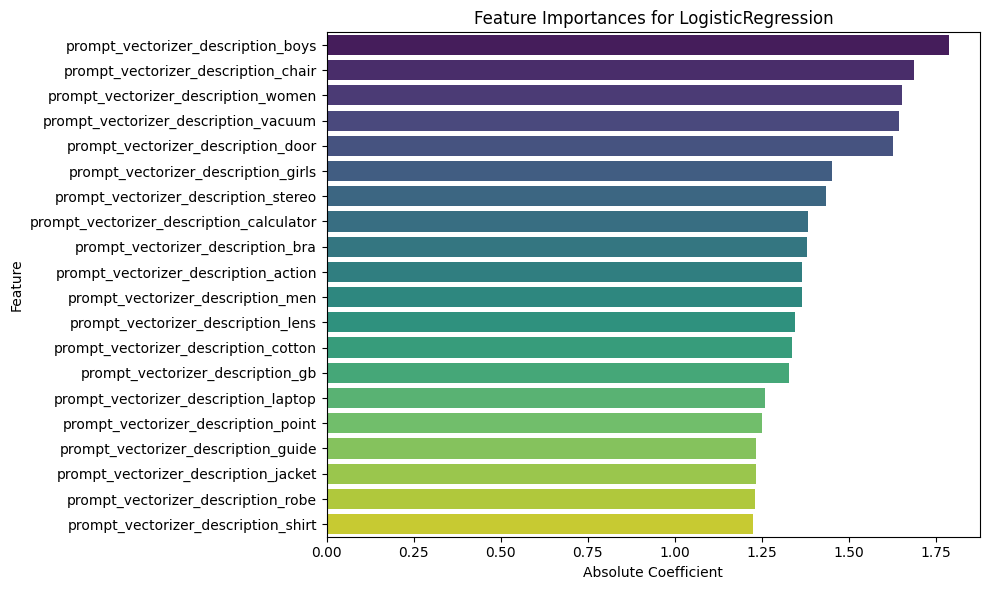

<Figure size 1500x600 with 0 Axes>

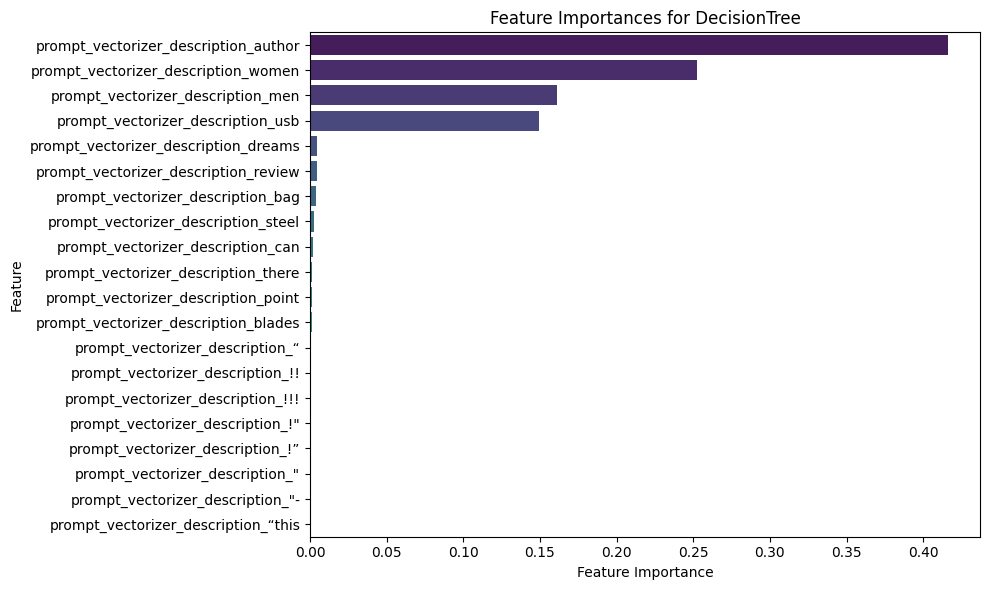

<Figure size 1500x600 with 0 Axes>

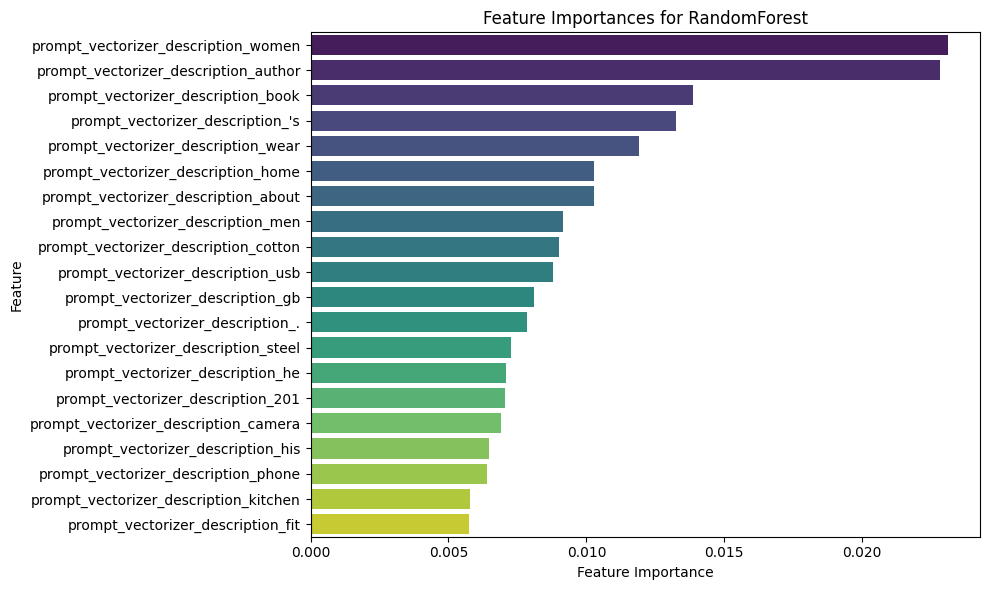

<Figure size 1500x600 with 0 Axes>

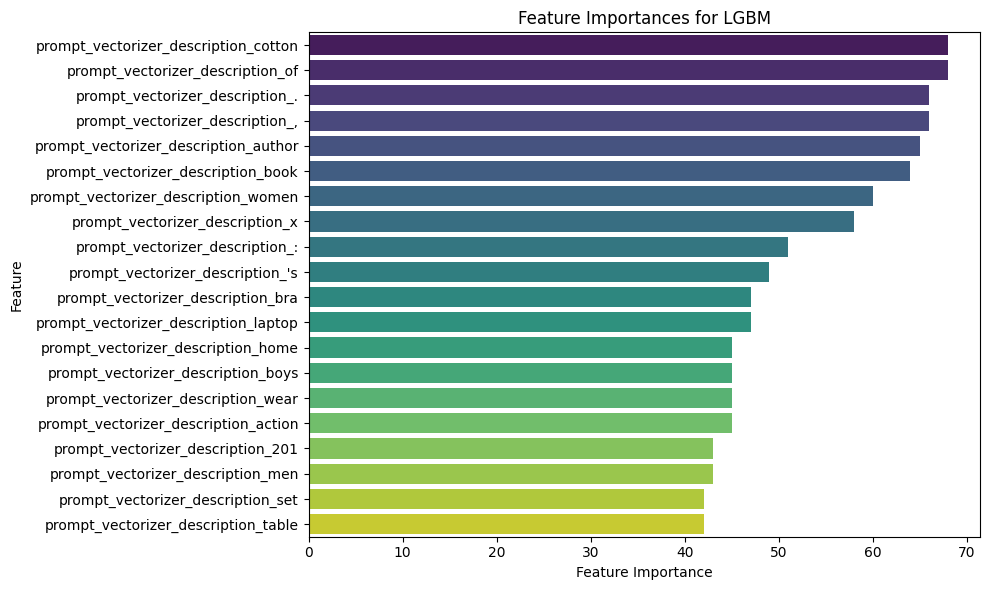

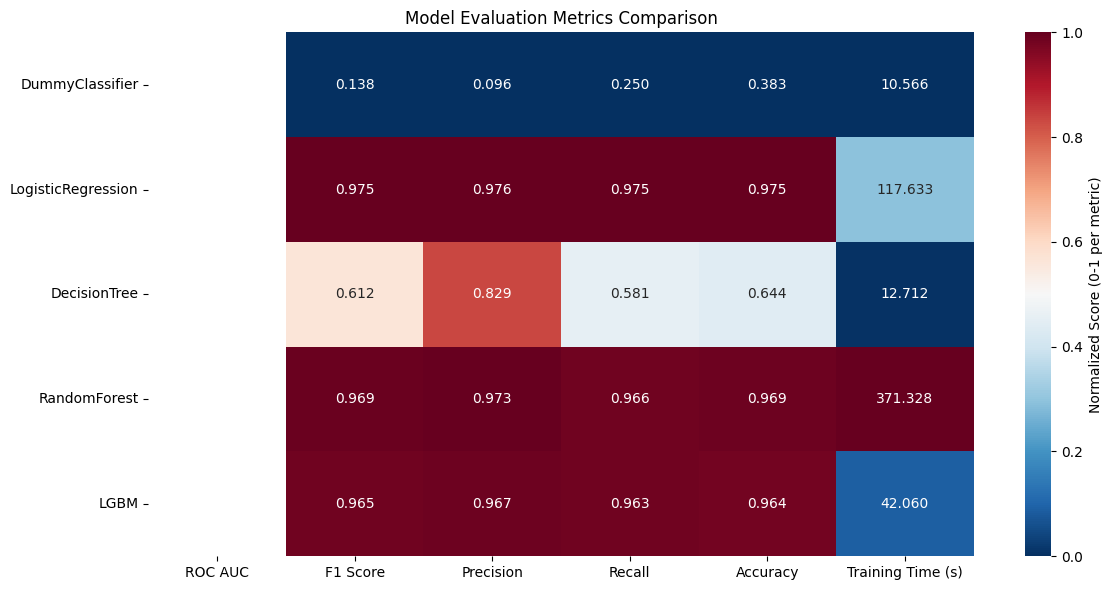

In [20]:
count_vectorizer_metrics = train_evaluate_models_cv(models, X, y, count_vectorizer_processor, cv, SEED)

Очень сильные результаты для базовых моделей. Пунктуация больше всех использовалась в LGBM, но и результаты метрик у нее ниже. Возможно, с удалением стоп-слов и пунктуации мы улучшим результат

#### С удалением стоп-слов и пунктуации

Также проверим как изменится качество моделей после удаления пунктуации и стоп-слов

In [23]:
X_cleaned = X.copy()
X_cleaned[['description']] = X_cleaned[['description']].map(lambda tokens: filter_tokens(
    tokens,
    remove_stopwords=True,
    remove_punctuation_tokens=True,
    lowercase_for_counting=True
))

X_cleaned.sample(5)

,description
47557,"[sun, robot, ics, gsm, external, ant, enna, 3,..."
19544,"[mer, ck, veterinary, manual, back, cover, mer..."
24441,"[happ, ens, die, psychic, 's, exploration, dea..."
42006,"[canon, l, bp, 603, 0, b, image, class, laser,..."
33146,"[inch, uk, kids, p, aj, amas, baby, p, aj, ama..."


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

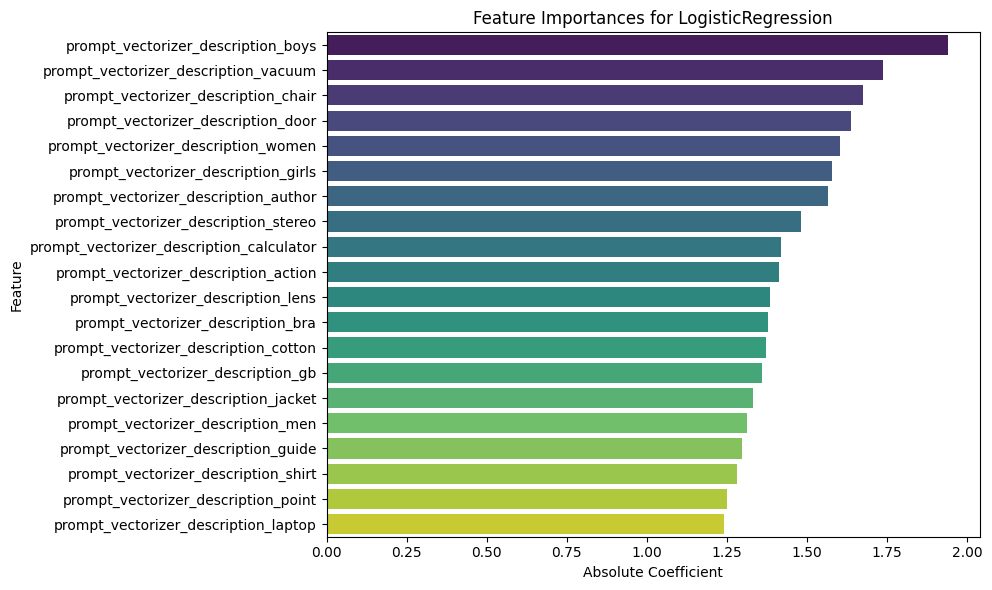

<Figure size 1500x600 with 0 Axes>

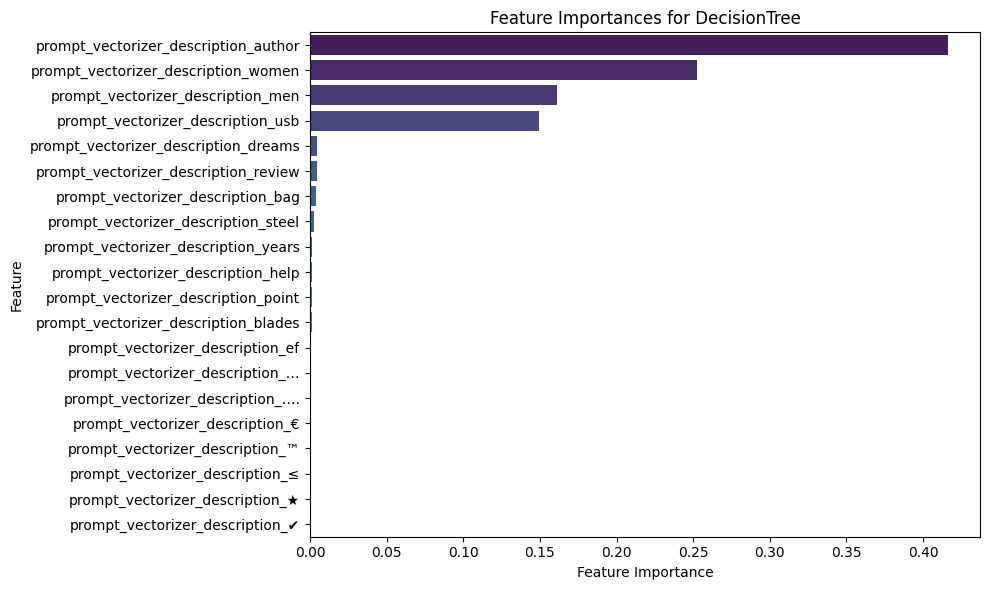

<Figure size 1500x600 with 0 Axes>

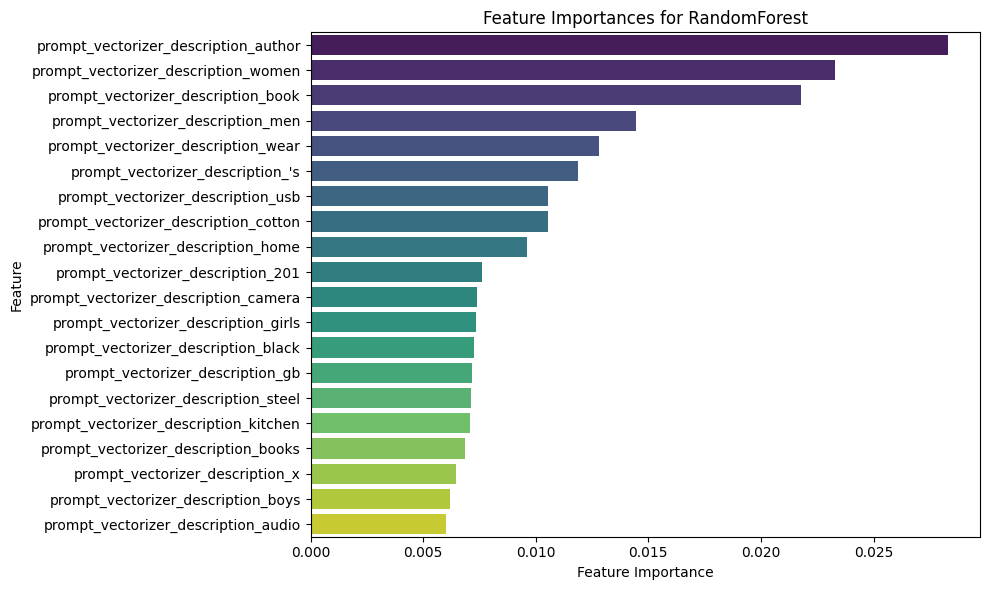

<Figure size 1500x600 with 0 Axes>

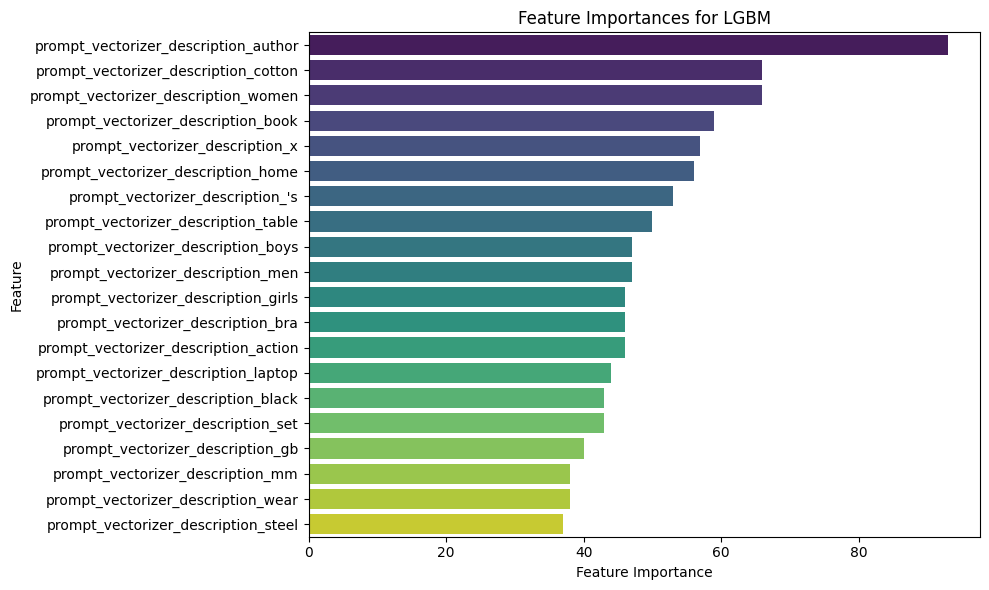

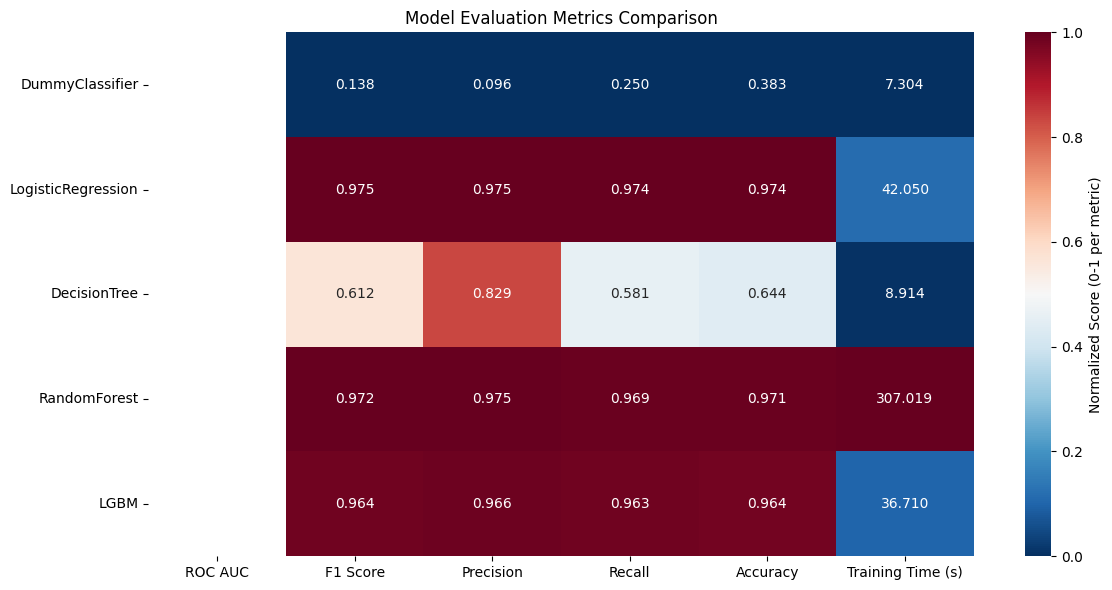

In [24]:
count_vecotrizer_cleaned_metrics = train_evaluate_models_cv(models, X_cleaned, y, count_vectorizer_processor, cv, SEED)

Сравниваем метрики моделей до и после удаления стоп-слов, тепловая карта покажет изменение качества метрик

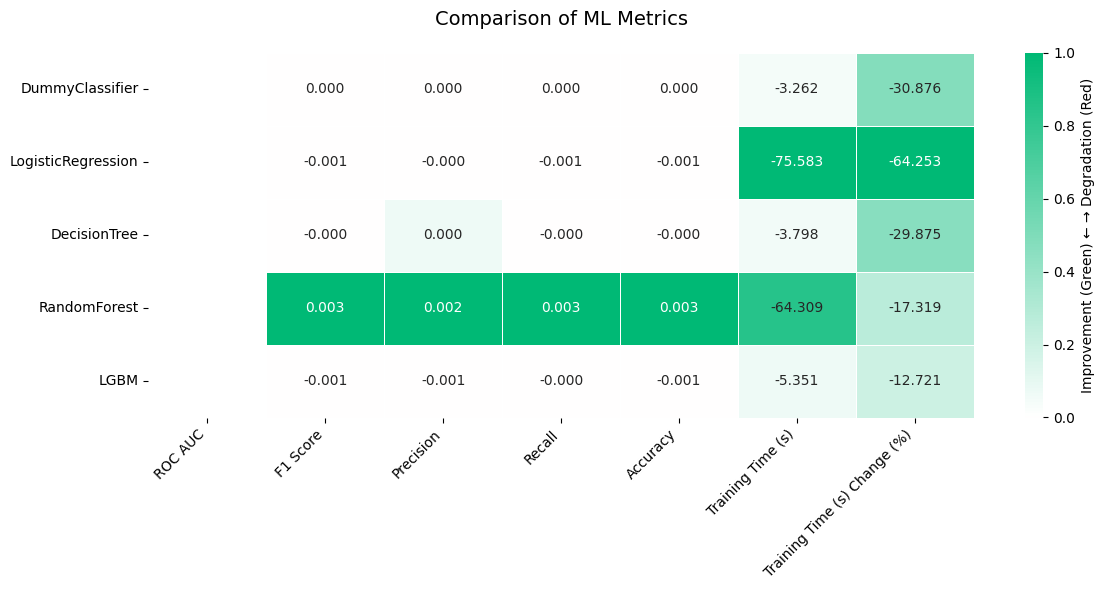

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,NaN,0.000000,0.000000,0.000000,0.000000,-3.262464,-30.876035
LogisticRegression,NaN,-0.000590,-0.000494,-0.000690,-0.000654,-75.583120,-64.253439
DecisionTree,NaN,-0.000018,0.000148,-0.000029,-0.000020,-3.797676,-29.875157
RandomForest,NaN,0.002603,0.002032,0.003041,0.002697,-64.308832,-17.318609
LGBM,NaN,-0.000504,-0.000618,-0.000385,-0.000535,-5.350626,-12.721354


In [25]:
delta = compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), count_vecotrizer_cleaned_metrics.to_dataframe())
delta

Изменение метрик незначительно, однако наблюдается прирост в скорости обучения, что делает данное преобразование целесообразным

#### Использование топ-100 важных токенов

Ограничим количество анализируемых токенов до 100 наиболее важных с целью еще большего ускорения обучения и улучшения качества линейных моделей

In [26]:
count_vectorizer_important_tokens_preprocessor = Pipeline([
    (
        'columns',
        ColumnTransformer([
            (
                'description_pipeline',
                Pipeline([
                    ('token_selector', NgramFeatureSelector(top_k=100)),
                    ('vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32))
                ]),
                'description'
            ),
        ], remainder='passthrough', verbose_feature_names_out=True)
    )
])

count_vectorizer_important_tokens_preprocessor

,steps,"[('columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('description_pipeline', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

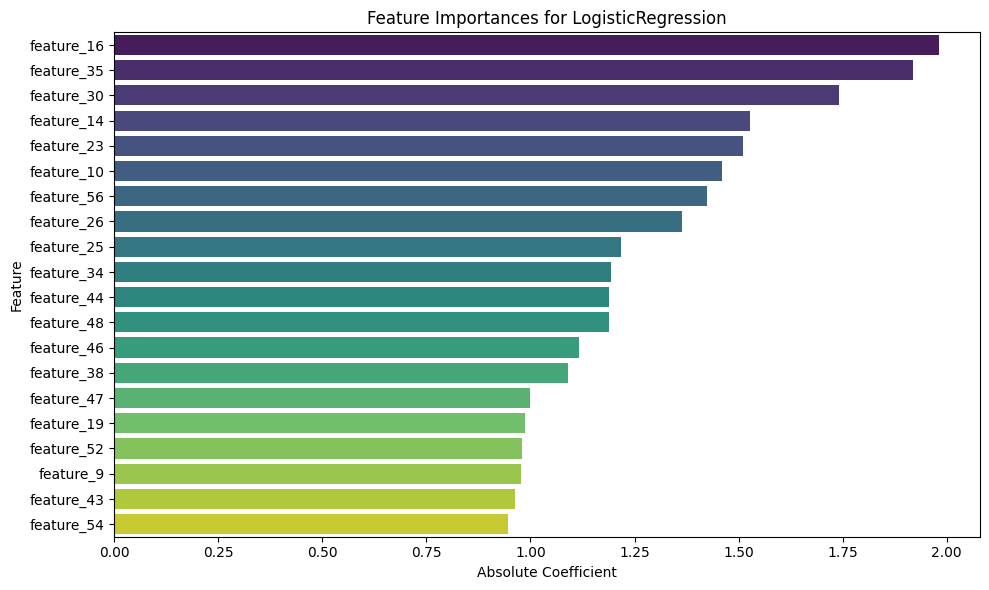

<Figure size 1500x600 with 0 Axes>

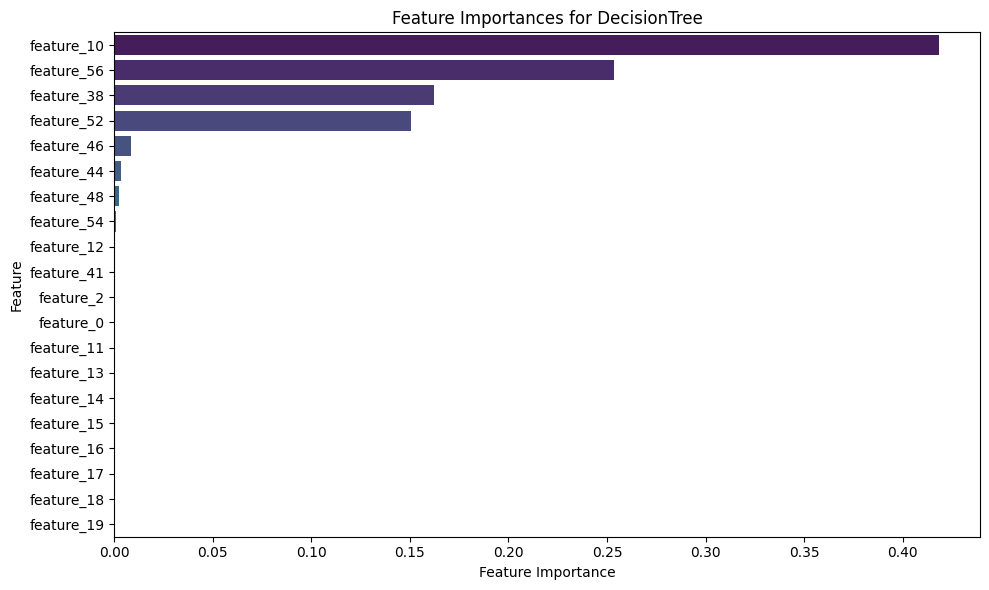

<Figure size 1500x600 with 0 Axes>

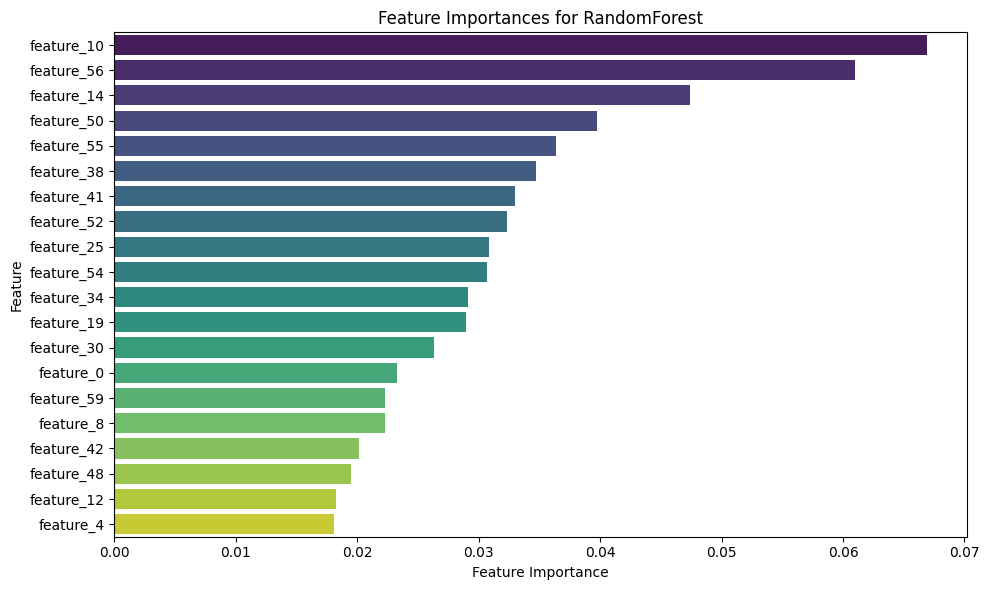

<Figure size 1500x600 with 0 Axes>

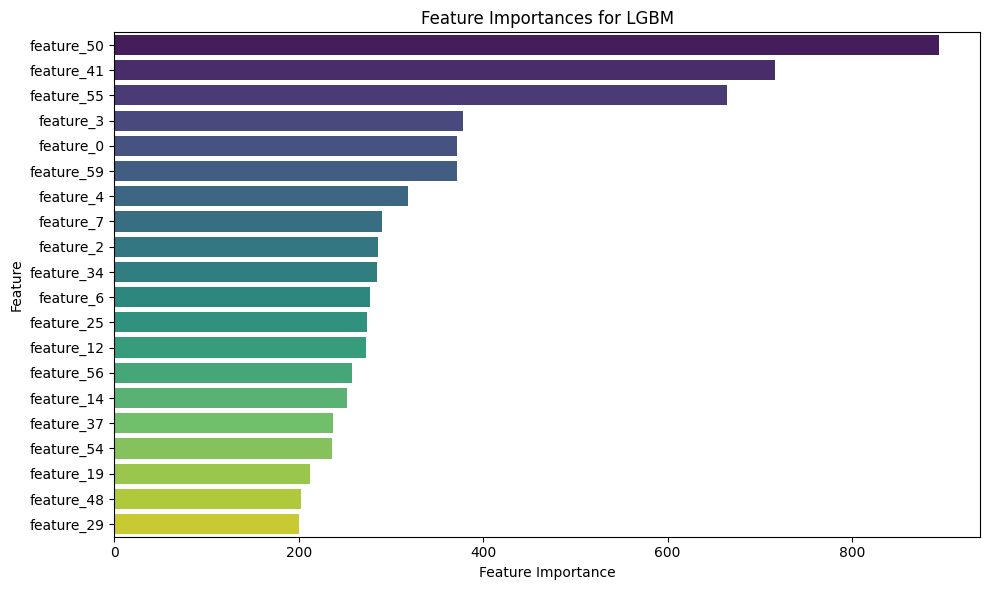

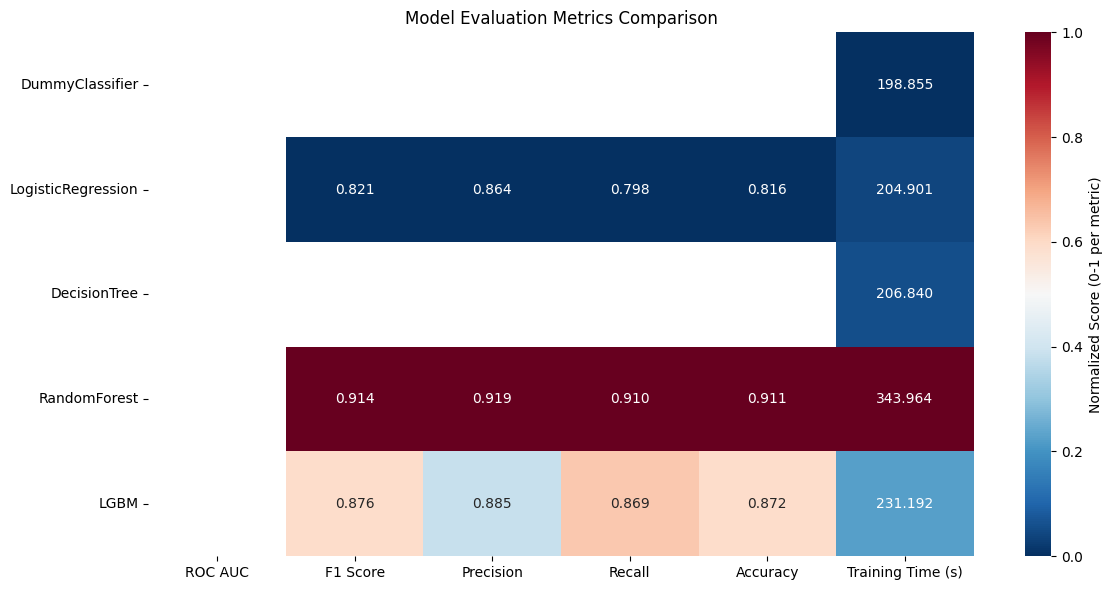

In [27]:
count_vectorizer_important_tokens_metrics = train_evaluate_models_cv(models, X, y, 
                                                                     count_vectorizer_important_tokens_preprocessor, cv, SEED)

Опять сравним метрики с помощью тепловой карты

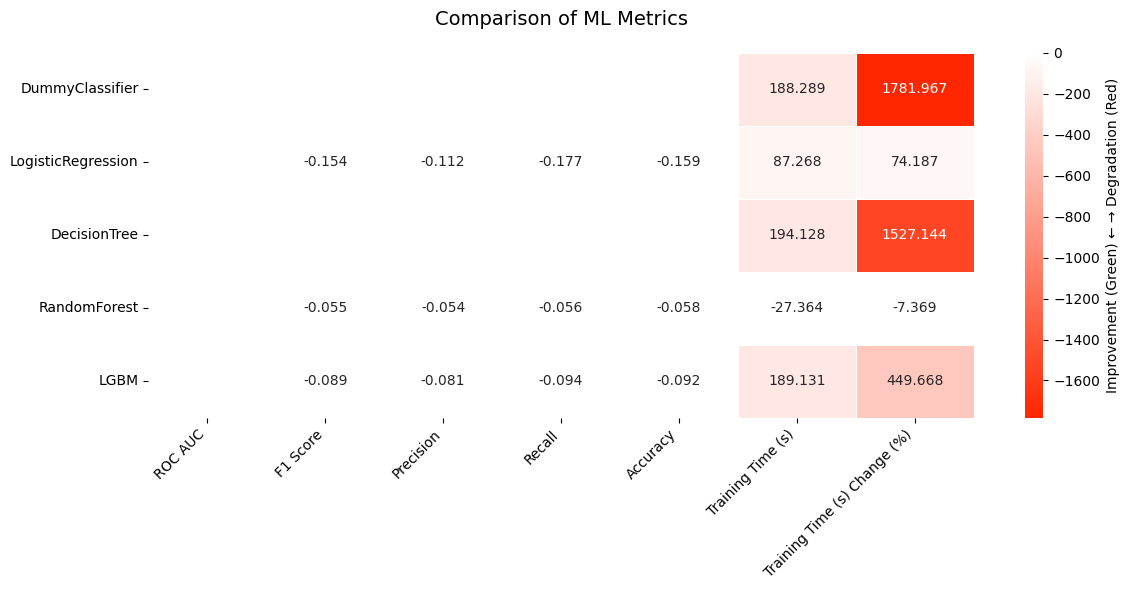

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,NaN,NaN,NaN,NaN,NaN,188.288510,1781.966810
LogisticRegression,NaN,-0.154326,-0.111713,-0.176996,-0.159250,87.267963,74.186760
DecisionTree,NaN,NaN,NaN,NaN,NaN,194.127752,1527.143890
RandomForest,NaN,-0.055462,-0.054001,-0.055708,-0.057631,-27.363893,-7.369199
LGBM,NaN,-0.089299,-0.081462,-0.094366,-0.091960,189.131406,449.668463


In [28]:
delta = compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), count_vectorizer_important_tokens_metrics.to_dataframe())
delta

Можно заметить, что метрики ухудшились + увеличилось время обучения за счет определения наиболее важных токенов

### TfidfVectorizer

TF-IDF (Term Frequency-Inverse Document Frequency) учитывает частоту слова в документе, и редкость слова в корпусе, что может дать лучшие результаты, чем простой подсчет частот

#### Без очистки токенов

Проверим работоспособность моделей без удаления потенциально ненужных токенов (пунктуация, стоп-слова)

In [29]:
tfidf_vectorizer_preprocessor = Pipeline([
    (
        'vectorizer',
        ColumnTransformer([
            ('description_vectorizer', TfidfVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'description'),
        ], remainder='passthrough', verbose_feature_names_out=True)
    )
])

tfidf_vectorizer_preprocessor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('description_vectorizer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

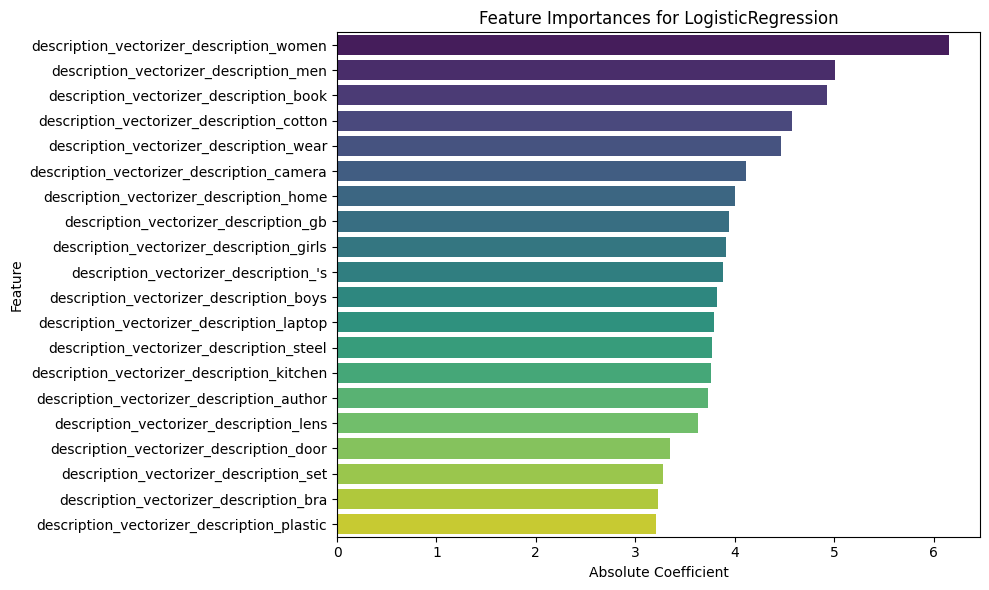

<Figure size 1500x600 with 0 Axes>

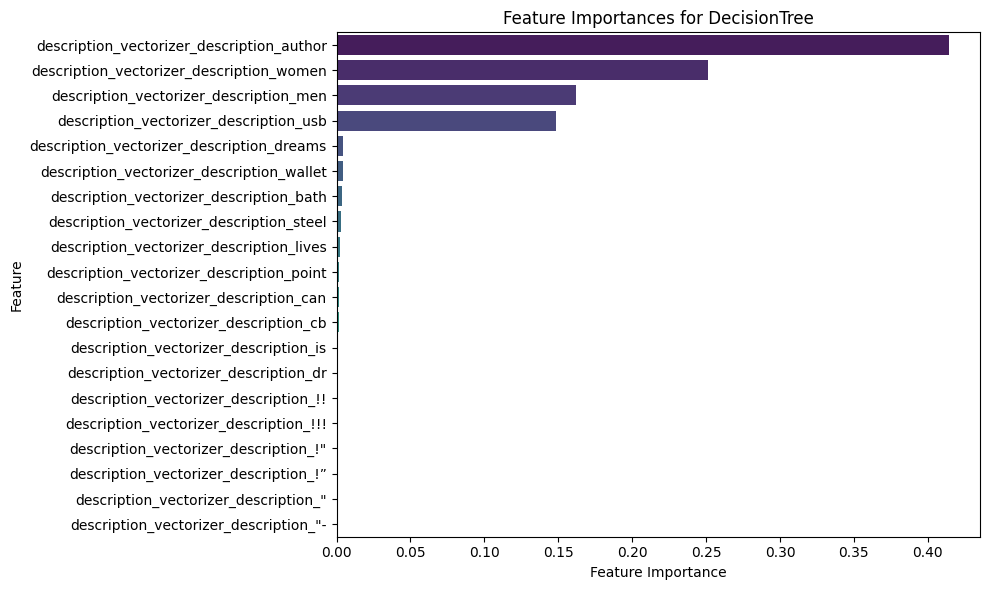

<Figure size 1500x600 with 0 Axes>

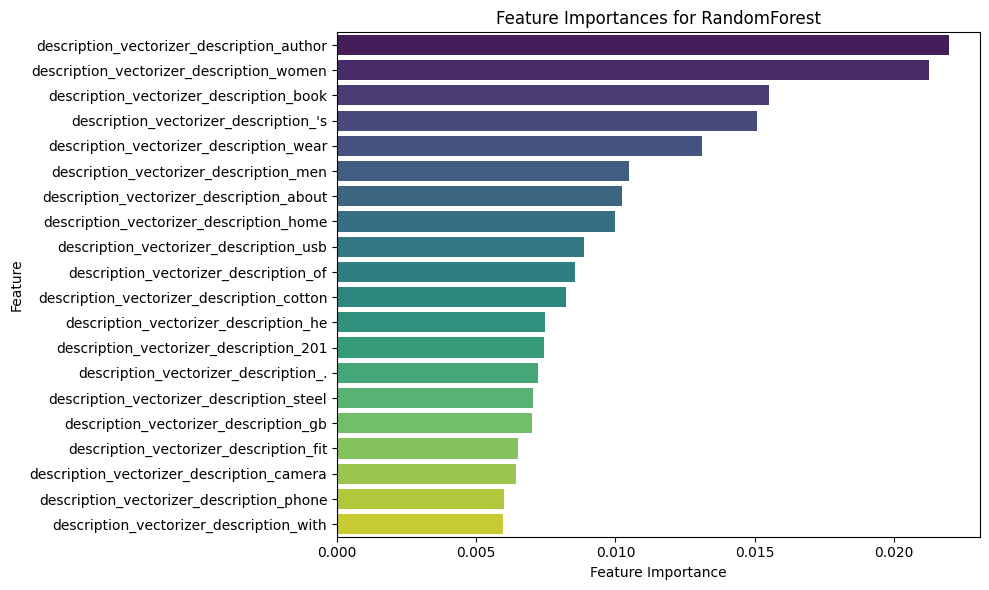

<Figure size 1500x600 with 0 Axes>

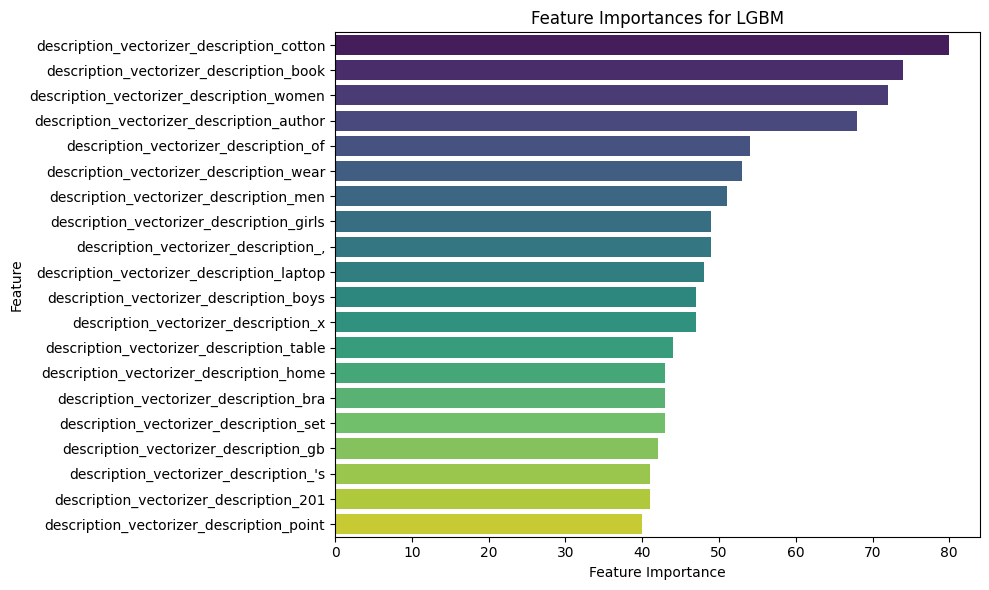

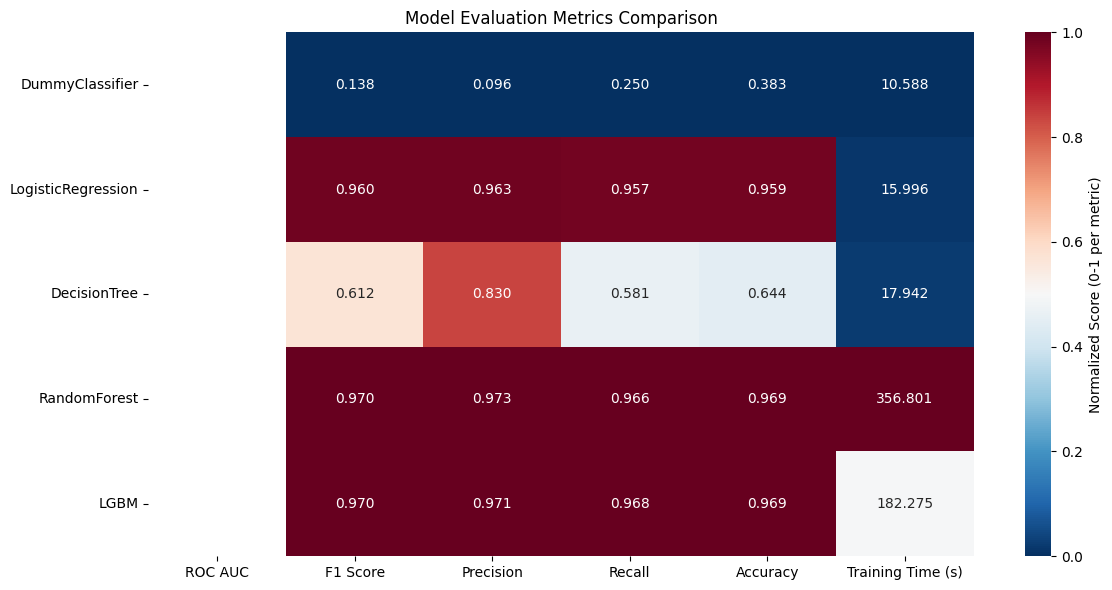

In [30]:
tfidf_vectorizer_metrics = train_evaluate_models_cv(models, X, y, tfidf_vectorizer_preprocessor, cv, SEED)

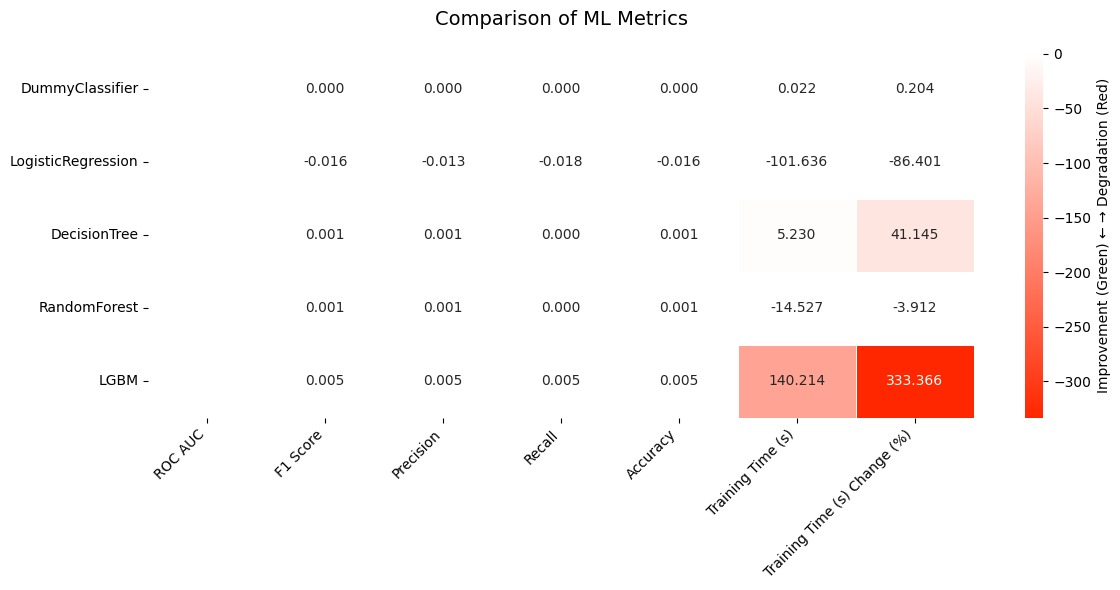

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,NaN,0.000000,0.000000,0.000000,0.000000,0.021576,0.204200
LogisticRegression,NaN,-0.015565,-0.013154,-0.017737,-0.016084,-101.636436,-86.401443
DecisionTree,NaN,0.000632,0.001212,0.000160,0.000516,5.230330,41.145409
RandomForest,NaN,0.000588,0.000765,0.000396,0.000615,-14.526900,-3.912149
LGBM,NaN,0.004844,0.004954,0.004717,0.004938,140.214364,333.365987


In [31]:
delta = compare_metrics_heatmap(count_vectorizer_metrics.to_dataframe(), tfidf_vectorizer_metrics.to_dataframe())
delta

Можно заметить, что качество моделей практически не изменилось, для некоторых увеличилось время обучения

#### С удалением стоп-слов

Проверим, улучшится ли качество TF-IDF после удаления пунктуации и стоп-слов

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

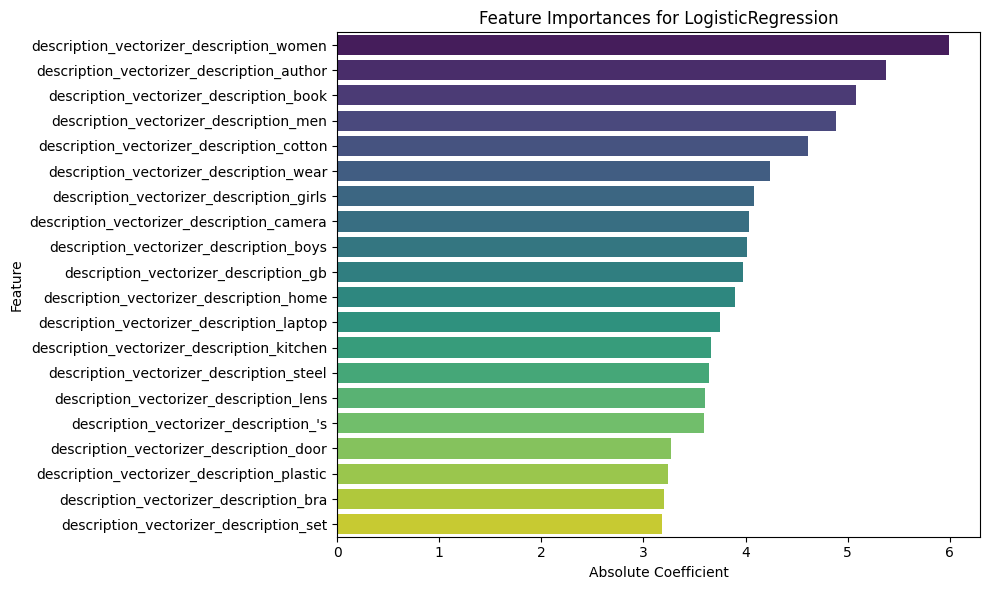

<Figure size 1500x600 with 0 Axes>

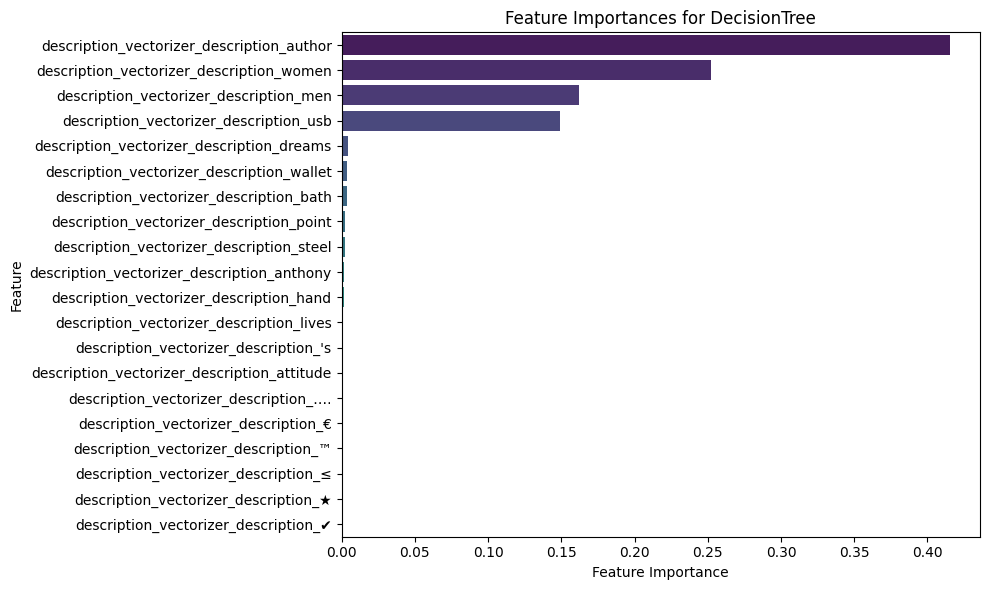

<Figure size 1500x600 with 0 Axes>

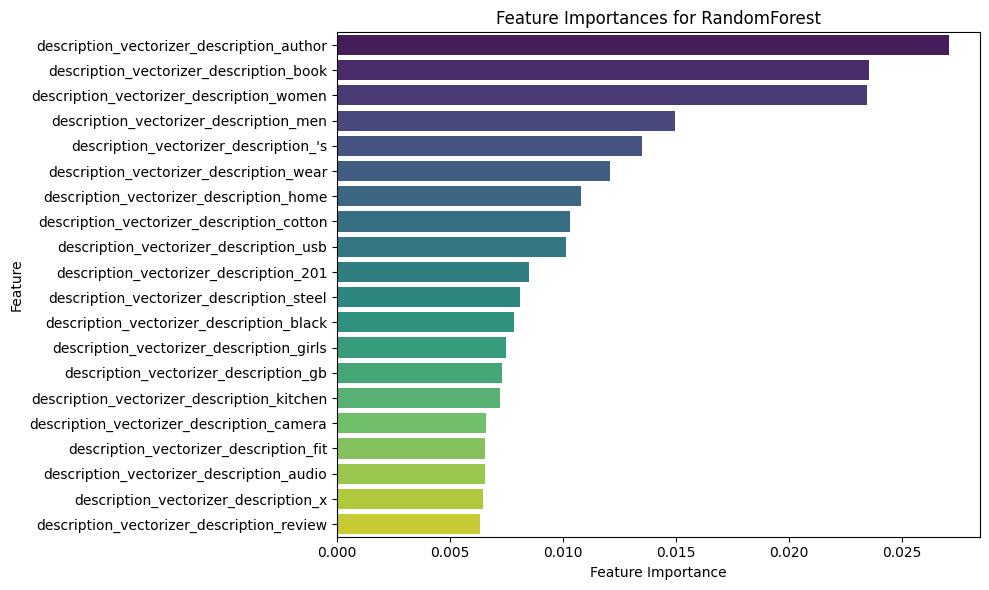

<Figure size 1500x600 with 0 Axes>

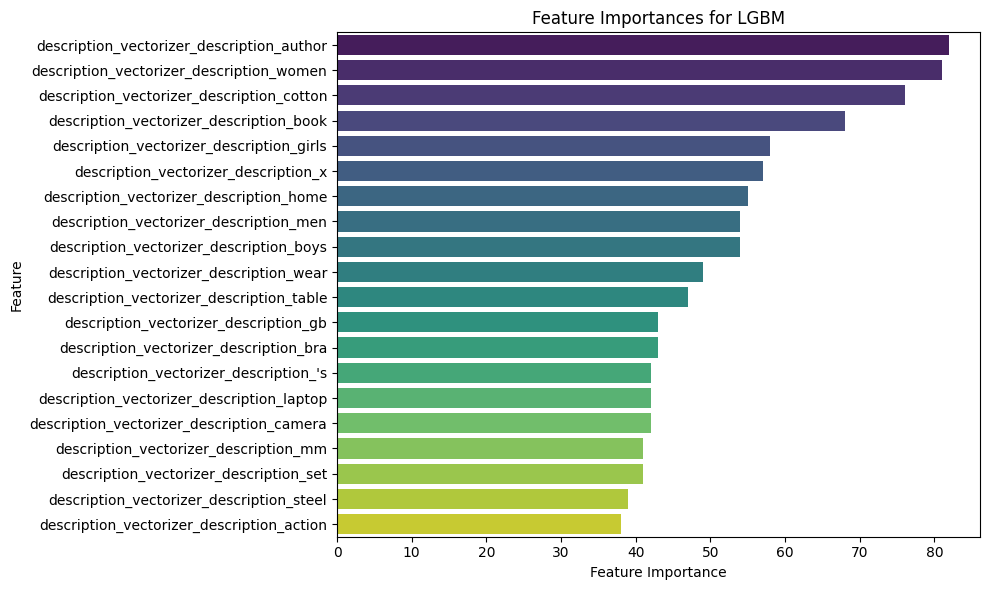

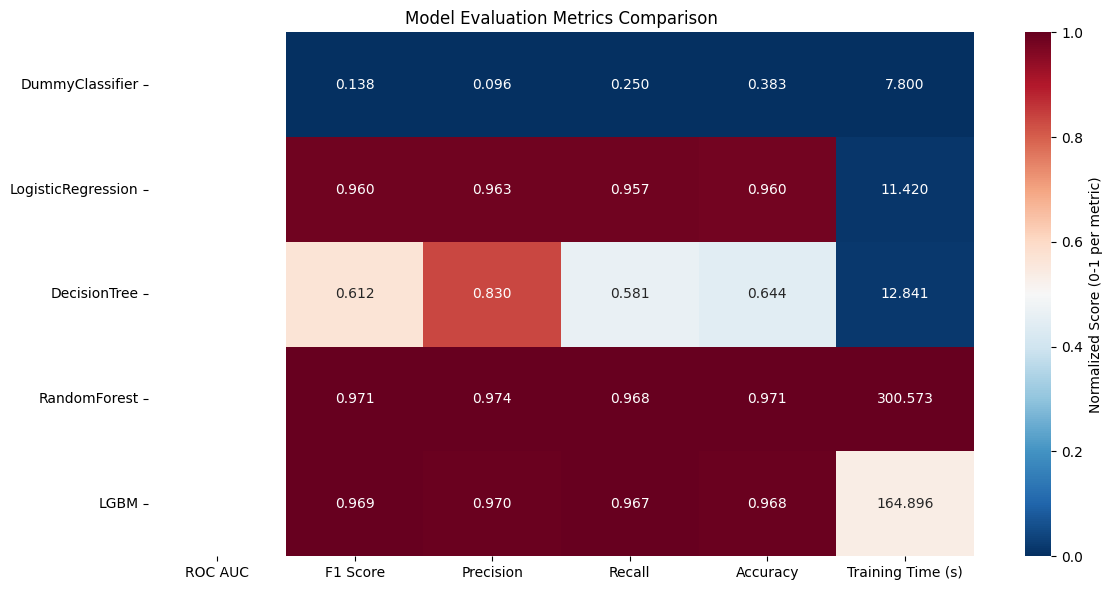

In [32]:
tfidf_vectorizer_cleaned_metrics = train_evaluate_models_cv(models, X_cleaned, y, tfidf_vectorizer_preprocessor, cv, SEED)

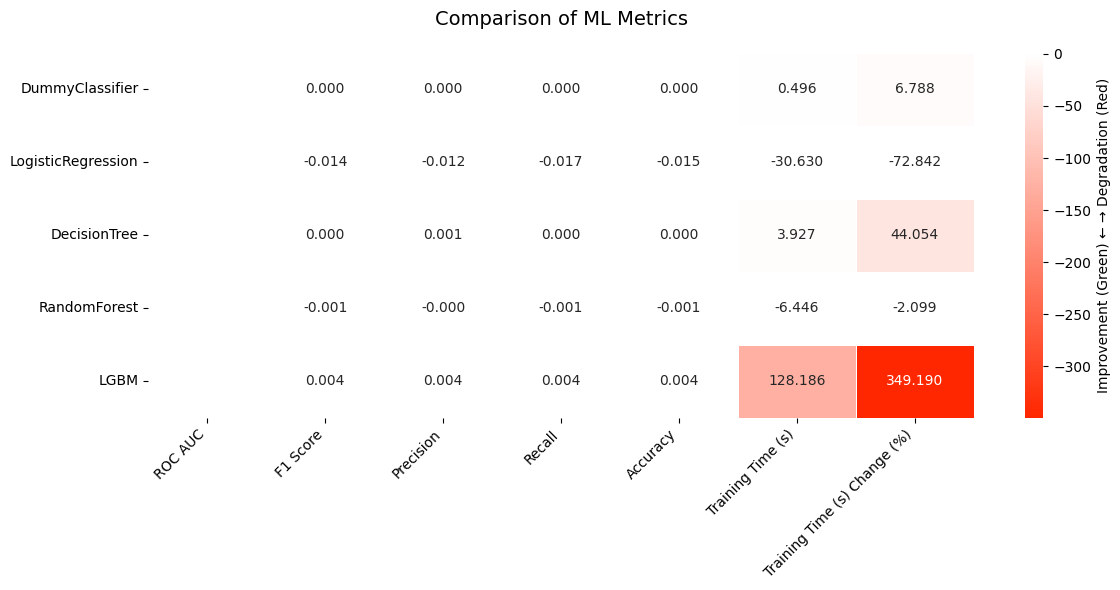

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,NaN,0.000000,0.000000,0.000000,0.000000,0.495771,6.787787
LogisticRegression,NaN,-0.014392,-0.011983,-0.016551,-0.014795,-30.629831,-72.842008
DecisionTree,NaN,0.000360,0.000759,0.000034,0.000357,3.927000,44.053588
RandomForest,NaN,-0.000798,-0.000349,-0.001197,-0.000793,-6.445701,-2.099446
LGBM,NaN,0.004145,0.004296,0.003974,0.004363,128.186191,349.190180


In [33]:
delta = compare_metrics_heatmap(count_vecotrizer_cleaned_metrics.to_dataframe(), tfidf_vectorizer_cleaned_metrics.to_dataframe())
delta

Видим, что удаление пунктуации и стоп-слов не принесло улучшений для TF-IDF что объяснимо тем, что данный алгоритм самостоятельно понижает важность подобных токенов

## Выводы

Лучший результат показала комбинация `CountVectorizer` и `LogisticRegression` без удаления стоп-слов и пунктуации

Далее сравним этот подход с нейросетями